In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from tqdm import tqdm
import librosa
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from matplotlib.patches import Ellipse
tqdm.pandas()


## 1. Dados

In [43]:
df = pd.read_parquet('/workspace/marcelo/Deepfake/SpecAnalysis/metrics_brpseechdf_reaper.parquet')

df['patient'] = df['path'].str.extract(r'/test/(.*?)/')[0]
df['spoof_model'] = np.where(
    df['patient'] == 'spoof',
    df['file'].str.extract(r'^(.*?)_')[0],
    'bonafide'
)

parts = df['file'].str.replace('.flac', '', regex=False).str.split('_', expand=True)
df['id1'] = np.where(df['patient'] == 'spoof', parts[1], parts[0])
df['id2'] = np.where(df['patient'] == 'spoof', parts[2], parts[1])
df['id3'] = np.where(df['patient'] == 'spoof', parts[3], parts[2])

print(df['spoof_model'].value_counts())
df.head()


spoof_model
bonafide       1316
f5tts          1316
toucantts      1316
xtts           1316
yourtts        1316
fish-speech    1311
Name: count, dtype: int64


,file,path,model,patient,times_reaper,f0_reaper,corr,spoof_model,id1,id2,id3
0,11247_10229_000006-0001.flac,/workspace/BRSpeech-DF/BRSpeech-DF/test/bonafi...,test,bonafide,"[0.0, 0.005, 0.01, 0.015, 0.02, 0.024999999, 0...","[-1.0, 212.38937, 205.1282, 201.68068, 196.721...","[0.0, 0.9184604, 0.9622038, 0.957536, 0.968477...",bonafide,11247,10229,000006-0001
1,11247_10229_000006-0004.flac,/workspace/BRSpeech-DF/BRSpeech-DF/test/bonafi...,test,bonafide,"[0.0, 0.005, 0.01, 0.015, 0.02, 0.024999999, 0...","[260.86957, 258.0645, 252.63158, 244.89796, 24...","[0.68192035, 0.837949, 0.96537936, 0.9821846, ...",bonafide,11247,10229,000006-0004
2,11247_10229_000006-0002.flac,/workspace/BRSpeech-DF/BRSpeech-DF/test/bonafi...,test,bonafide,"[0.0, 0.005, 0.01, 0.015, 0.02, 0.024999999, 0...","[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1....","[0.0, 0.27889445, 0.25832644, 0.32199246, 0.32...",bonafide,11247,10229,000006-0002
3,11247_10229_000006-0003.flac,/workspace/BRSpeech-DF/BRSpeech-DF/test/bonafi...,test,bonafide,"[0.0, 0.005, 0.01, 0.015, 0.02, 0.024999999, 0...","[179.10448, 171.42857, 171.42857, 167.83217, 1...","[0.93527883, 0.8822389, 0.8822389, 0.9577233, ...",bonafide,11247,10229,000006-0003
4,11247_10229_000031-0001.flac,/workspace/BRSpeech-DF/BRSpeech-DF/test/bonafi...,test,bonafide,"[0.0, 0.005, 0.01, 0.015, 0.02, 0.024999999, 0...","[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1....","[0.3354297, 0.3354297, 0.58607525, 0.6280401, ...",bonafide,11247,10229,000031-0001


## 2. Seleção de Speaker

In [44]:
SPEAKER = "11247"
df_sp = df[df["id1"].astype(str) == SPEAKER].copy()
print(f"Utterances: {len(df_sp)} "
      f"(bonafide={len(df_sp[df_sp['patient']=='bonafide'])}, "
      f"spoof={len(df_sp[df_sp['patient']!='bonafide'])})")


Utterances: 594 (bonafide=99, spoof=495)


## 3. Funções auxiliares

In [45]:
# ── pause segmentation (shared by all extraction functions) ─────────────────
def _segments(mask):
    ch = np.diff(mask.astype(int), prepend=0, append=0)
    return np.where(ch == 1)[0], np.where(ch == -1)[0]

def _pause_mask(f0):
    return np.asarray(f0, dtype=float) < 0

# ── feature extractors ───────────────────────────────────────────────────────
def extract_pauses(times, f0, hop_s=0.005):
    """Duração, contagem e proporção de pausas (f0 < 0 = REAPER não vocalizado)."""
    t = np.asarray(times, dtype=float)
    is_pause = _pause_mask(f0)
    starts, ends = _segments(is_pause)

    durs = []
    for s, e in zip(starts, ends):
        dur = (t[e-1] - t[s]) * 1000 + hop_s * 1000 if s < len(t) and (e-1) < len(t) else (e-s)*hop_s*1000
        durs.append(dur)

    total_ms = len(t) * hop_s * 1000
    pause_ms = sum(durs)
    return {
        "n_pauses": len(durs), "pause_durations_ms": durs,
        "total_dur_ms": total_ms, "pause_total_ms": pause_ms,
        "pause_ratio":  pause_ms / total_ms if total_ms > 0 else np.nan,
        "pause_mean_ms":   np.mean(durs)   if durs else np.nan,
        "pause_median_ms": np.median(durs) if durs else np.nan,
        "pause_std_ms":    np.std(durs)    if durs else np.nan,
        "n_short": sum(d <  200 for d in durs),
        "n_long":  sum(d >= 200 for d in durs),
    }


def pause_positions(times, f0, hop_s=0.005):
    """Posição relativa de cada pausa na utterance (0=início, 1=fim)."""
    t = np.asarray(times, dtype=float)
    is_pause = _pause_mask(f0)
    starts, ends = _segments(is_pause)
    total = len(t)

    if len(starts) == 0 or total == 0:
        return {"pos_mean": np.nan, "prop_inicio": np.nan, "prop_meio": np.nan, "prop_fim": np.nan}

    pos = [(s + e) / 2 / total for s, e in zip(starts, ends)]
    return {
        "pos_mean":    np.mean(pos),
        "prop_inicio": sum(p <  0.25 for p in pos) / len(pos),
        "prop_meio":   sum(0.25 <= p < 0.75 for p in pos) / len(pos),
        "prop_fim":    sum(p >= 0.75 for p in pos) / len(pos),
    }


def inter_pause(times, f0, hop_s=0.005):
    """Intervalo entre pausas consecutivas. CV baixo → ritmo regular demais (TTS)."""
    t = np.asarray(times, dtype=float)
    is_pause = _pause_mask(f0)
    starts, ends = _segments(is_pause)

    if len(ends) < 2:
        return {"ipi_mean_ms": np.nan, "ipi_std_ms": np.nan, "ipi_cv": np.nan}

    pairs = [(ends[i], starts[i+1]) for i in range(len(ends)-1)
             if i+1 < len(starts) and starts[i+1] > ends[i]]
    if not pairs:
        return {"ipi_mean_ms": np.nan, "ipi_std_ms": np.nan, "ipi_cv": np.nan}

    ivals = [(t[min(e2-1, len(t)-1)] - t[e1]) * 1000 for e1, e2 in pairs]
    mean, std = np.mean(ivals), np.std(ivals)
    return {"ipi_mean_ms": mean, "ipi_std_ms": std, "ipi_cv": std/mean if mean > 0 else np.nan}


def pause_speech_ratio(times, f0, hop_s=0.005):
    """Razão duração-pausa / segmento-vocalizado-anterior. Menor variabilidade → TTS."""
    t = np.asarray(times, dtype=float)
    is_pause = _pause_mask(f0)
    pauses = list(zip(*_segments(is_pause)))
    voiced = list(zip(*_segments(~is_pause)))

    if not pauses or not voiced:
        return {"psr_mean": np.nan, "psr_std": np.nan}

    ratios = []
    for ps, pe in pauses:
        prev = [(vs, ve) for vs, ve in voiced if ve <= ps]
        if not prev:
            continue
        vs, ve = prev[-1]
        dv = (ve - vs) * hop_s * 1000
        if dv > 0:
            ratios.append((pe - ps) * hop_s * 1000 / dv)
    return {"psr_mean": np.mean(ratios) if ratios else np.nan,
            "psr_std":  np.std(ratios)  if ratios else np.nan}


def silence_rms(audio_path, times, f0, hop_s=0.005, sr=16000):
    """RMS médio (dB) nos segmentos de silêncio da utterance."""
    y, _ = librosa.load(audio_path, sr=sr, mono=True)
    t = np.asarray(times, dtype=float)
    starts, ends = _segments(_pause_mask(f0))

    if len(starts) == 0:
        return np.nan

    rms_vals = []
    for s, e in zip(starts, ends):
        seg = y[int(t[s]*sr):int(t[min(e, len(t)-1)]*sr)]
        if len(seg) > 0:
            rms_vals.append(librosa.amplitude_to_db(np.sqrt(np.mean(seg**2)) + 1e-9))
    return np.mean(rms_vals) if rms_vals else np.nan


# ── plotting helpers ─────────────────────────────────────────────────────────
def make_palette(pt):
    models = pt["spoof_model"].unique()
    return models, dict(zip(models, plt.cm.tab10(np.linspace(0, 1, len(models)))))

def boxplot_col(ax, pt, models, colors, col, title):
    data = [pt[pt["spoof_model"] == m][col].dropna().values for m in models]
    bp = ax.boxplot(data, patch_artist=True, medianprops=dict(color="black", lw=2), widths=0.5)
    for patch, m in zip(bp["boxes"], models):
        patch.set_facecolor(colors[m]); patch.set_alpha(0.75)
    ax.set_xticks(range(1, len(models)+1))
    ax.set_xticklabels(models, rotation=35, ha="right", fontsize=9)
    ax.set_title(title); ax.grid(axis="y", alpha=0.3)


## 4. Extração de features

In [46]:
pt = df_sp.progress_apply(
    lambda row: pd.Series({
        **extract_pauses(row["times_reaper"], row["f0_reaper"]),
        **pause_positions(row["times_reaper"], row["f0_reaper"]),
        **inter_pause(row["times_reaper"], row["f0_reaper"]),
        **pause_speech_ratio(row["times_reaper"], row["f0_reaper"]),
        "file": row["file"], "patient": row["patient"], "spoof_model": row["spoof_model"],
    }), axis=1
)

# REAPER correlation features
pt["corr_mean"]    = df_sp["corr"].apply(lambda x: np.mean([v for v in np.asarray(x) if v > 0])).values
pt["corr_std"]     = df_sp["corr"].apply(lambda x: np.std([v for v in np.asarray(x) if v > 0])).values
pt["corr_voiced"]  = df_sp.apply(lambda row: np.mean(np.asarray(row["corr"])[np.asarray(row["f0_reaper"]) > 0]), axis=1).values
pt["corr_silence"] = df_sp.apply(lambda row: np.mean(np.asarray(row["corr"])[np.asarray(row["f0_reaper"]) < 0]), axis=1).values

# Silence RMS
pt["silence_rms_db"] = df_sp.progress_apply(
    lambda row: silence_rms(row["path"], row["times_reaper"], row["f0_reaper"]), axis=1
).values

pt.drop(columns=["pause_durations_ms"]).head()


100%|██████████| 594/594 [00:05<00:00, 106.00it/s]


,n_pauses,total_dur_ms,pause_total_ms,pause_ratio,pause_mean_ms,pause_median_ms,pause_std_ms,n_short,n_long,pos_mean,...,psr_mean,psr_std,file,patient,spoof_model,corr_mean,corr_std,corr_voiced,corr_silence,silence_rms_db
0,8,2660.0,1129.999989,0.424812,141.249999,95.000033,156.659448,7,1,0.513393,...,0.974095,1.019922,11247_10229_000006-0001.flac,bonafide,bonafide,0.660676,0.348197,0.933904,0.249564,-39.343265
1,1,1465.0,549.999957,0.375427,549.999957,549.999957,0.000000,0,1,0.812287,...,0.601093,0.000000,11247_10229_000006-0004.flac,bonafide,bonafide,0.764242,0.280868,0.963957,0.397432,-66.557770
2,4,2985.0,909.999807,0.304858,227.499952,142.499928,216.405303,2,2,0.517588,...,0.145455,0.083025,11247_10229_000006-0002.flac,bonafide,bonafide,0.764065,0.293498,0.940667,0.331713,-53.946125
3,2,430.0,139.999965,0.325581,69.999983,69.999983,15.000001,2,0,0.732558,...,0.491634,0.032175,11247_10229_000006-0003.flac,bonafide,bonafide,0.767334,0.286371,0.924521,0.355700,-51.599468
4,5,3020.0,1314.999872,0.435430,262.999974,179.999952,204.171473,3,2,0.607781,...,0.930871,0.796086,11247_10229_000031-0001.flac,bonafide,bonafide,0.703224,0.317250,0.949994,0.336859,-47.792214


## 5. Tabela estatística (Mann-Whitney)

In [47]:
METRICS = [
    ("n_pauses",        "Nº de pausas"),
    ("pause_ratio",     "Proporção silêncio/total"),
    ("pause_mean_ms",   "Duração média (ms)"),
    ("pause_median_ms", "Duração mediana (ms)"),
    ("pause_std_ms",    "Desvio padrão (ms)"),
    ("n_short",         "Pausas curtas (<200 ms)"),
    ("n_long",          "Pausas longas (≥200 ms)"),
]

bon = pt[pt["spoof_model"] == "bonafide"]
models_tts = [m for m in pt["spoof_model"].unique() if m != "bonafide"]

rows = []
for col, label in METRICS:
    row = {"Métrica": label, "bonafide (md)": round(bon[col].median(), 3)}
    for m in models_tts:
        spo = pt[pt["spoof_model"] == m][col].dropna()
        _, p = stats.mannwhitneyu(bon[col].dropna(), spo, alternative="two-sided")
        row[f"{m} (md)"] = round(spo.median(), 3)
        row[f"{m} (p)"]  = round(p, 4)
        row[f"{m} sig."] = "✓" if p < 0.05 else "✗"
    rows.append(row)

pd.DataFrame(rows)


,Métrica,bonafide (md),f5tts (md),f5tts (p),f5tts sig.,fish-speech (md),fish-speech (p),fish-speech sig.,toucantts (md),toucantts (p),toucantts sig.,xtts (md),xtts (p),xtts sig.,yourtts (md),yourtts (p),yourtts sig.
0,Nº de pausas,33.000,29.000,0.0654,✗,31.000,0.7715,✗,31.00,0.4771,✗,30.000,0.3974,✗,30.000,0.3155,✗
1,Proporção silêncio/total,0.396,0.401,0.5516,✗,0.372,0.0008,✓,0.31,0.0000,✓,0.355,0.0000,✓,0.379,0.0672,✗
2,Duração média (ms),172.660,185.333,0.0237,✓,161.579,0.0011,✓,141.71,0.0000,✓,147.200,0.0000,✓,212.432,0.0000,✓
3,Duração mediana (ms),125.000,115.000,0.0003,✓,127.500,0.8846,✗,110.00,0.0000,✓,104.999,0.0000,✓,155.000,0.0000,✓
4,Desvio padrão (ms),156.659,197.281,0.0000,✓,131.789,0.0000,✓,101.80,0.0000,✓,136.213,0.0571,✗,196.234,0.0000,✓
5,Pausas curtas (<200 ms),25.000,23.000,0.2244,✗,25.000,0.9416,✗,25.00,0.8040,✗,25.000,0.8232,✗,20.000,0.0009,✓
6,Pausas longas (≥200 ms),8.000,6.000,0.0072,✓,6.000,0.2289,✗,5.00,0.0003,✓,5.000,0.0002,✓,9.000,0.0001,✓


## 6. Visualizações

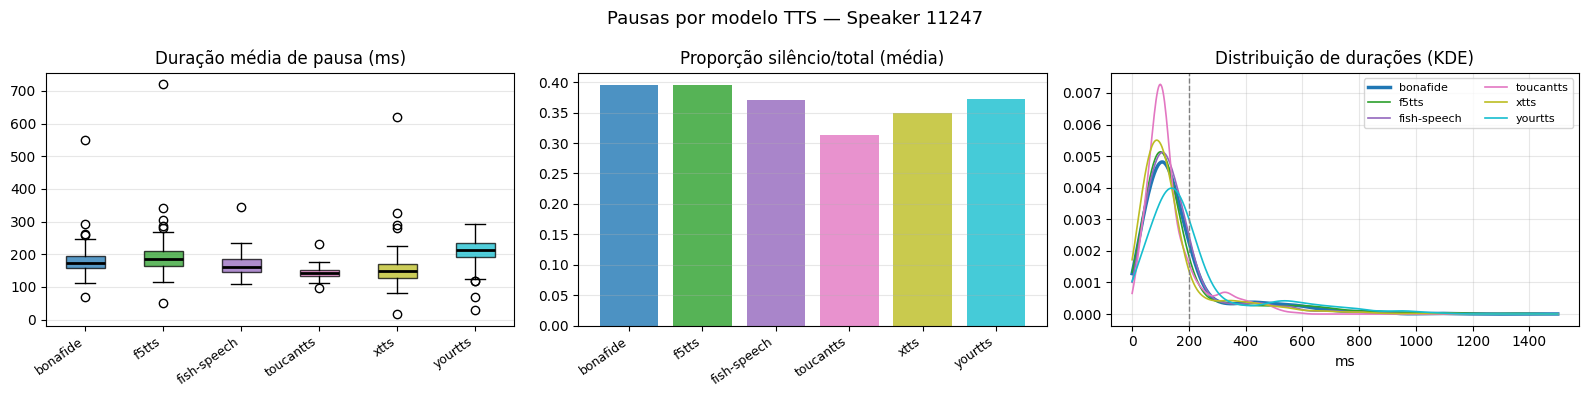

In [48]:
models, colors = make_palette(pt)
CAP_MS = 1500

# ── 6.1 Duração e proporção de pausas ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f"Pausas por modelo TTS — Speaker {SPEAKER}", fontsize=13)

boxplot_col(axes[0], pt, models, colors, "pause_mean_ms", "Duração média de pausa (ms)")

means = [pt[pt["spoof_model"] == m]["pause_ratio"].mean() for m in models]
axes[1].bar(range(len(models)), means, color=[colors[m] for m in models], alpha=0.8)
axes[1].set_xticks(range(len(models)))
axes[1].set_xticklabels(models, rotation=35, ha="right", fontsize=9)
axes[1].set_title("Proporção silêncio/total (média)"); axes[1].grid(axis="y", alpha=0.3)

ax = axes[2]
for m, color in colors.items():
    arr = np.concatenate(pt[pt["spoof_model"] == m]["pause_durations_ms"].tolist())
    arr = arr[arr <= CAP_MS]
    if len(arr) > 1:
        kde = stats.gaussian_kde(arr, bw_method="scott")
        x = np.linspace(0, CAP_MS, 500)
        ax.plot(x, kde(x), color=color, label=m, lw=2.5 if m=="bonafide" else 1.2)
ax.axvline(200, color="gray", ls="--", lw=1)
ax.set_title("Distribuição de durações (KDE)")
ax.set_xlabel("ms"); ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()


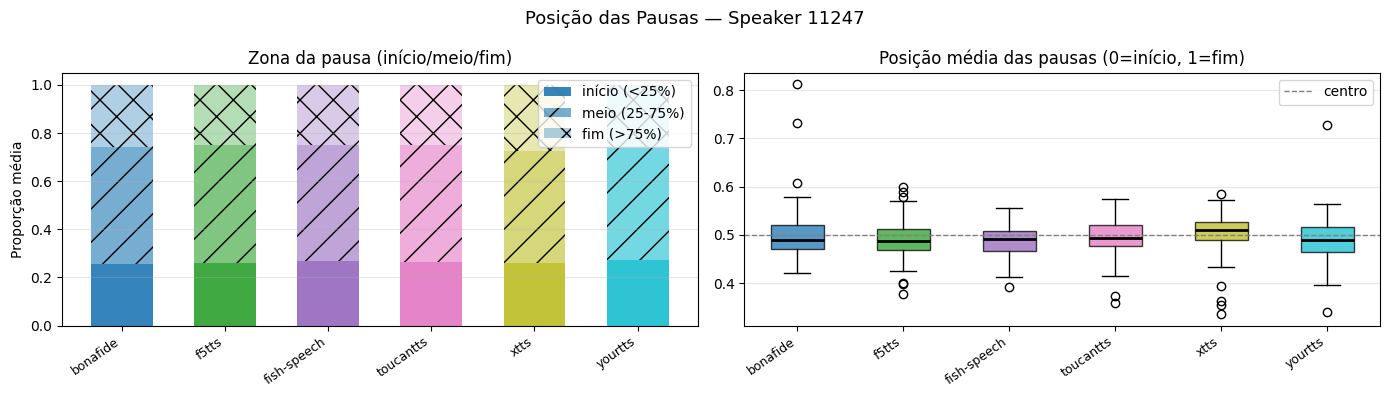

In [49]:
# ── 6.2 Posição das pausas ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f"Posição das Pausas — Speaker {SPEAKER}", fontsize=13)

ax = axes[0]
x, w, bot = np.arange(len(models)), 0.6, np.zeros(len(models))
for zona, hatch, alpha in [("prop_inicio","",0.9),("prop_meio","/",0.6),("prop_fim","x",0.35)]:
    vals = [pt[pt["spoof_model"]==m][zona].mean() for m in models]
    ax.bar(x, vals, w, bottom=bot, label=zona.replace("prop_",""),
           color=[colors[m] for m in models], alpha=alpha, hatch=hatch)
    bot += np.array(vals)
ax.set_xticks(x); ax.set_xticklabels(models, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Proporção média"); ax.set_title("Zona da pausa (início/meio/fim)")
ax.legend(["início (<25%)","meio (25-75%)","fim (>75%)"]); ax.grid(axis="y", alpha=0.3)

boxplot_col(axes[1], pt, models, colors, "pos_mean", "Posição média das pausas (0=início, 1=fim)")
axes[1].axhline(0.5, color="gray", ls="--", lw=1, label="centro"); axes[1].legend()

plt.tight_layout(); plt.show()


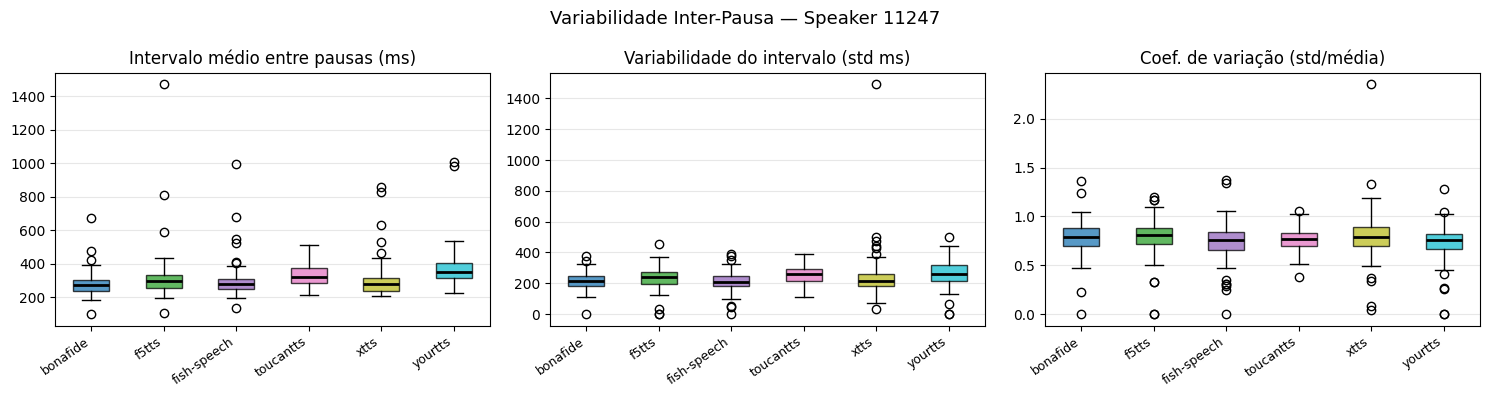

In [50]:
# ── 6.3 Variabilidade inter-pausa ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"Variabilidade Inter-Pausa — Speaker {SPEAKER}", fontsize=13)
for ax, (col, title) in zip(axes, [
    ("ipi_mean_ms","Intervalo médio entre pausas (ms)"),
    ("ipi_std_ms", "Variabilidade do intervalo (std ms)"),
    ("ipi_cv",     "Coef. de variação (std/média)"),
]):
    boxplot_col(ax, pt, models, colors, col, title)
plt.tight_layout(); plt.show()


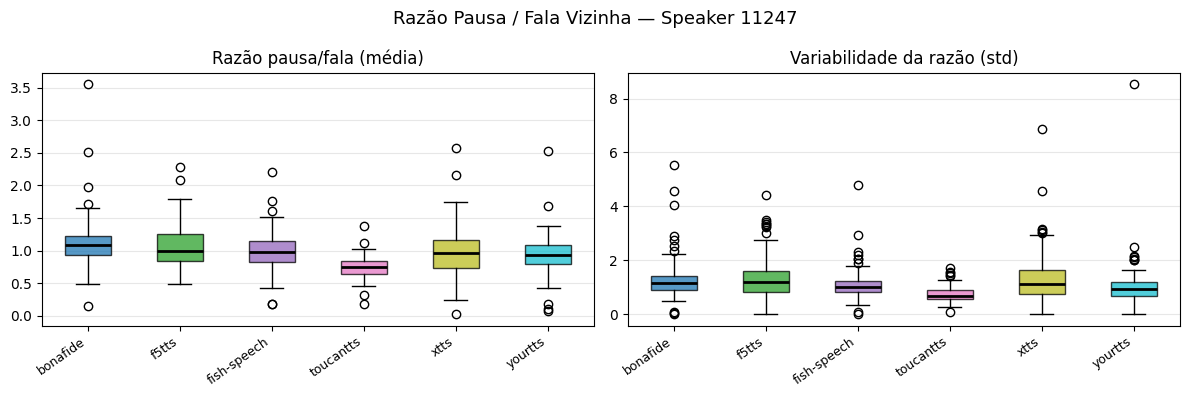

In [51]:
# ── 6.4 Razão pausa / fala vizinha ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"Razão Pausa / Fala Vizinha — Speaker {SPEAKER}", fontsize=13)
for ax, (col, title) in zip(axes, [
    ("psr_mean","Razão pausa/fala (média)"),
    ("psr_std", "Variabilidade da razão (std)"),
]):
    boxplot_col(ax, pt, models, colors, col, title)
plt.tight_layout(); plt.show()


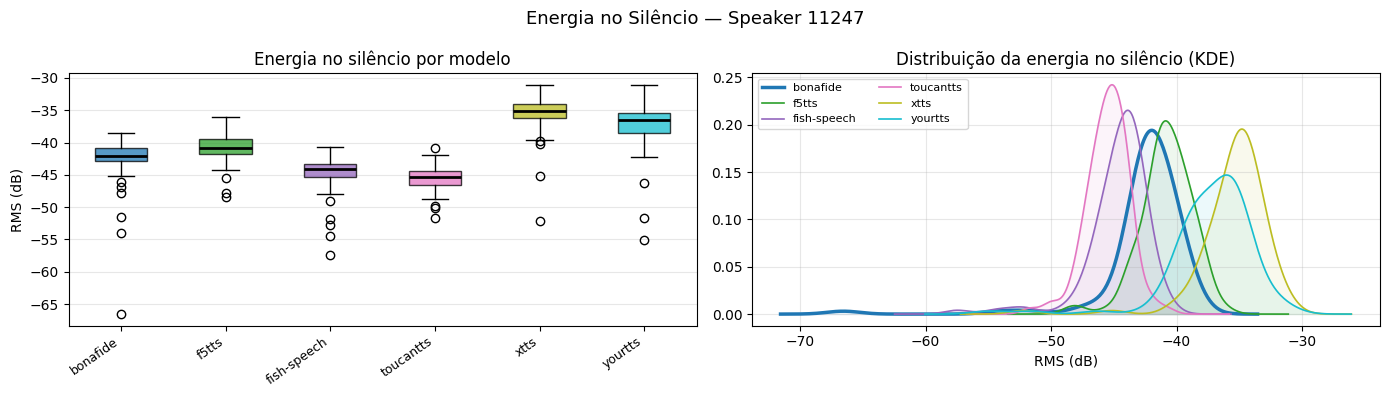

In [52]:
# ── 6.5 Energia no silêncio (RMS) ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f"Energia no Silêncio — Speaker {SPEAKER}", fontsize=13)

boxplot_col(axes[0], pt, models, colors, "silence_rms_db", "Energia no silêncio por modelo")
axes[0].set_ylabel("RMS (dB)")

ax = axes[1]
for m, color in colors.items():
    arr = pt[pt["spoof_model"] == m]["silence_rms_db"].dropna().values
    if len(arr) > 1:
        kde = stats.gaussian_kde(arr, bw_method="scott")
        x = np.linspace(arr.min()-5, arr.max()+5, 400)
        ax.plot(x, kde(x), color=color, label=m, lw=2.5 if m=="bonafide" else 1.2)
        ax.fill_between(x, kde(x), alpha=0.08, color=color)
ax.set_xlabel("RMS (dB)"); ax.set_title("Distribuição da energia no silêncio (KDE)")
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()


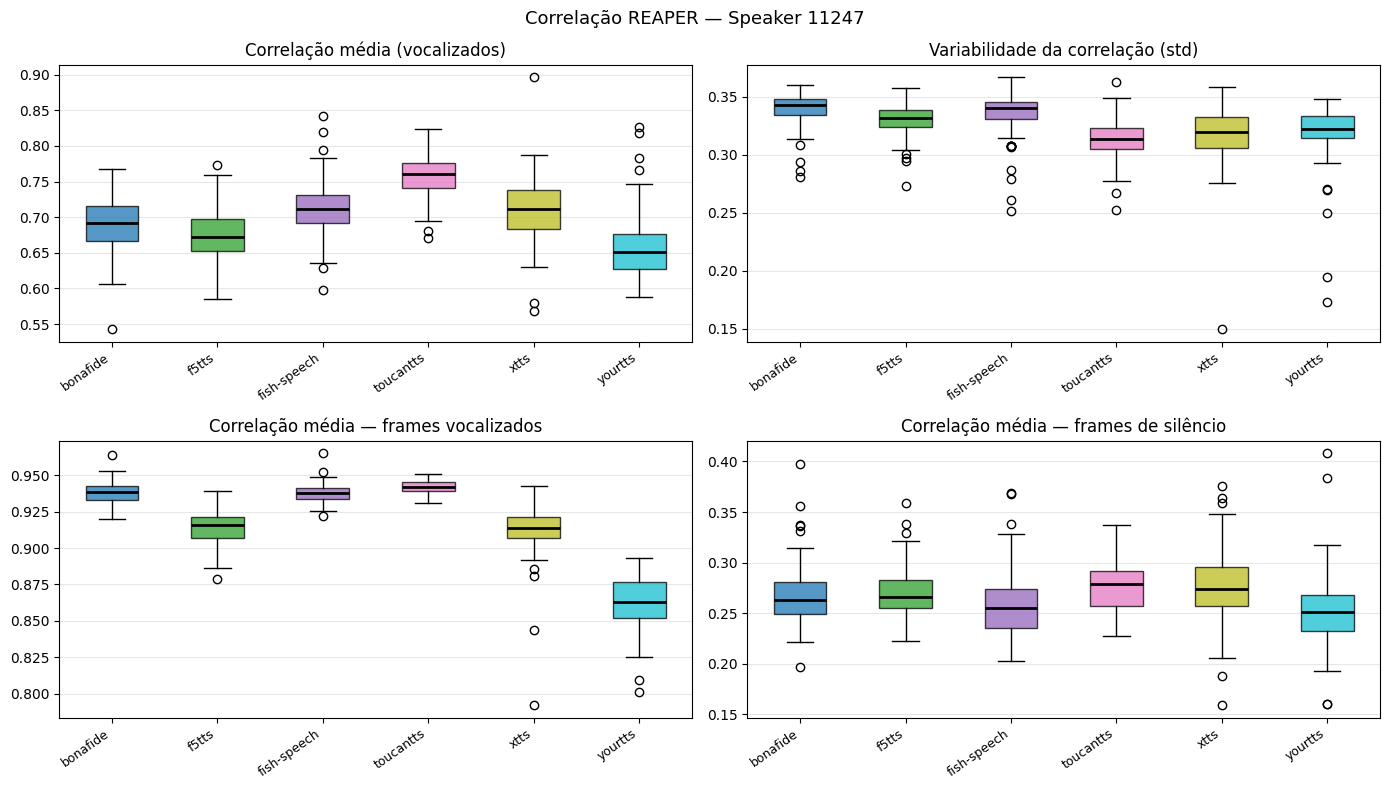

In [53]:
# ── 6.6 Correlação REAPER ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f"Correlação REAPER — Speaker {SPEAKER}", fontsize=13)
for ax, (col, title) in zip(axes.flatten(), [
    ("corr_mean",    "Correlação média (vocalizados)"),
    ("corr_std",     "Variabilidade da correlação (std)"),
    ("corr_voiced",  "Correlação média — frames vocalizados"),
    ("corr_silence", "Correlação média — frames de silêncio"),
]):
    boxplot_col(ax, pt, models, colors, col, title)
plt.tight_layout(); plt.show()


## 7. Redução dimensional & importância de features

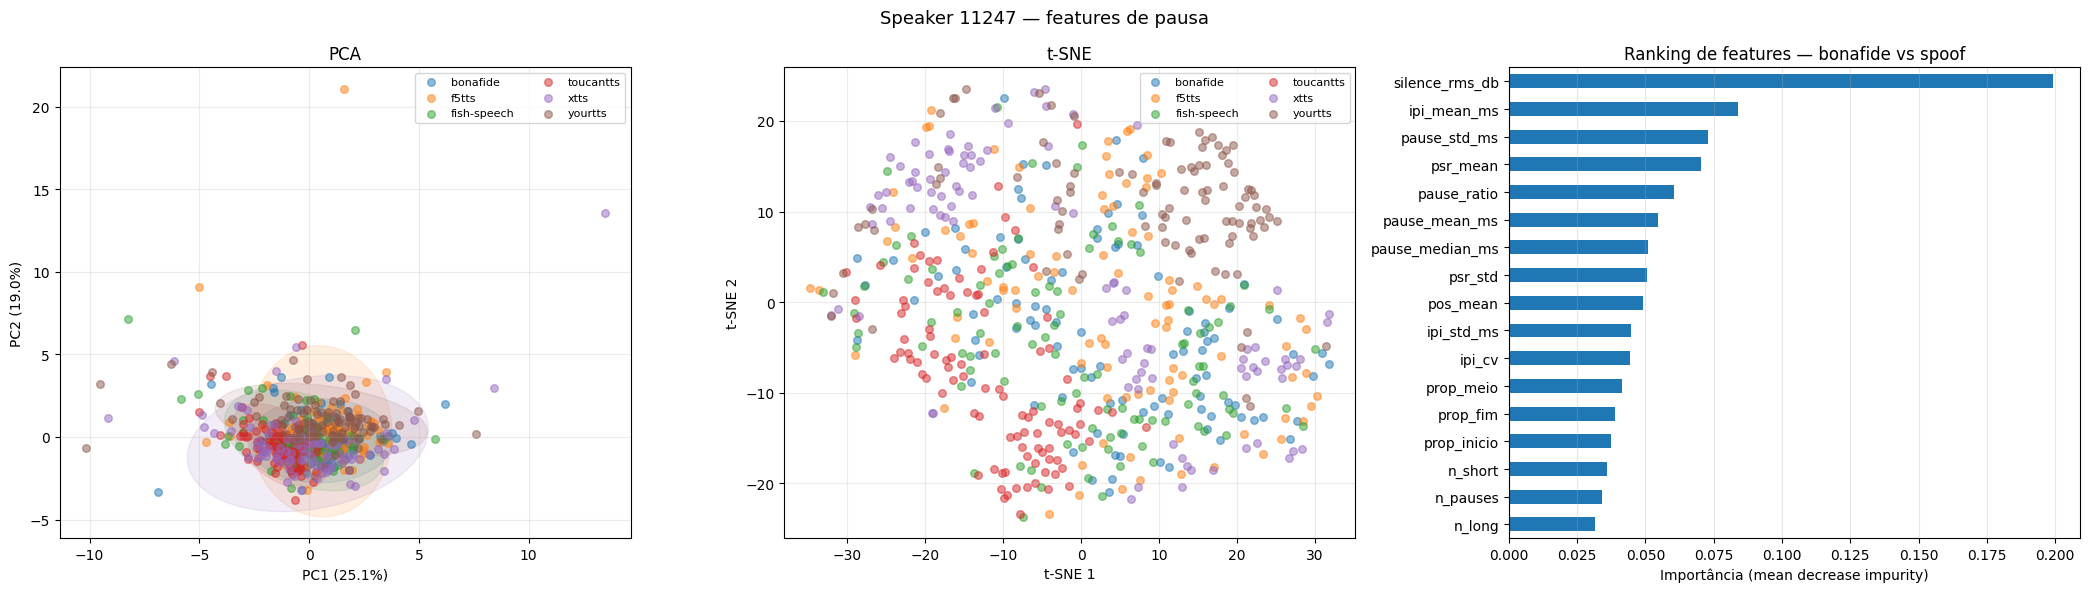

In [54]:
PAUSE_FEATURES = [
    "n_pauses","pause_ratio","pause_mean_ms","pause_median_ms","pause_std_ms",
    "n_short","n_long","pos_mean","prop_inicio","prop_meio","prop_fim",
    "ipi_mean_ms","ipi_std_ms","ipi_cv","psr_mean","psr_std","silence_rms_db",
]

pt_ml = pt[PAUSE_FEATURES + ["spoof_model"]].dropna().copy()
X = StandardScaler().fit_transform(pt_ml[PAUSE_FEATURES])

# PCA
coords = PCA(n_components=2).fit(X)
pca    = coords
coords = pca.fit_transform(X)
pt_ml[["PC1","PC2"]] = coords
var1, var2 = pca.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle(f"Speaker {SPEAKER} — features de pausa", fontsize=13)

# PCA scatter
ax = axes[0]
for m, sub in pt_ml.groupby("spoof_model"):
    sc = ax.scatter(sub["PC1"], sub["PC2"], label=m, alpha=0.5, s=30)
    if len(sub) > 2:
        cov = np.cov(sub["PC1"], sub["PC2"])
        vals, vecs = np.linalg.eigh(cov)
        idx = vals.argsort()[::-1]; vals, vecs = vals[idx], vecs[:,idx]
        w, h = 2*2.0*np.sqrt(vals)
        ell = Ellipse((sub["PC1"].mean(), sub["PC2"].mean()), w, h,
                      angle=np.degrees(np.arctan2(*vecs[:,0][::-1])),
                      color=sc.get_facecolor()[0], alpha=0.12, zorder=0)
        ax.add_patch(ell)
ax.set_xlabel(f"PC1 ({var1:.1f}%)"); ax.set_ylabel(f"PC2 ({var2:.1f}%)")
ax.set_title("PCA"); ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.25)

# t-SNE
tsne_coords = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X)
pt_ml[["tSNE1","tSNE2"]] = tsne_coords
ax = axes[1]
for m, sub in pt_ml.groupby("spoof_model"):
    ax.scatter(sub["tSNE1"], sub["tSNE2"], label=m, alpha=0.5, s=30)
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
ax.set_title("t-SNE"); ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.25)

# Random Forest feature importance
y_bin = (pt_ml["spoof_model"] != "bonafide").astype(int)
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1).fit(X, y_bin)
importances = pd.Series(rf.feature_importances_, index=PAUSE_FEATURES).sort_values(ascending=True)
importances.plot(kind="barh", ax=axes[2])
axes[2].set_xlabel("Importância (mean decrease impurity)")
axes[2].set_title("Ranking de features — bonafide vs spoof"); axes[2].grid(axis="x", alpha=0.3)

plt.tight_layout(); plt.show()
